In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib
import pandas as pd

from numpy.polynomial.polynomial import Polynomial

In [10]:
def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

In [4]:
# Load the data (replace this with your CSV data loading method)
df = pd.read_csv('/mnt/data/HarmonyBatch/GPU_profiling_batches_1_to_24.csv')  # Update with your CSV file path
# df = df[df['Batch_size'] == 1]  # Filter only batch size = 1
# df = df[df['total_latency']]
# Group data by 'vCPU' and calculate the average of 'Min_latency(ms)' across different 'Memory' configurations
df_avg_latency = df.groupby('batch')['Total_latency(ms)'].mean().reset_index()
# df_avg_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])

# Now you have the average minimum latency for each vCPU across different memory configurations
X = df_avg_latency['batch'].values.reshape(-1, 1)
y = df_avg_latency['Total_latency(ms)'].values

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

In [15]:
def fit_latency_vs_batch_size(
    file_path="/mnt/data/HarmonyBatch/GPU_profiling_batches_1_to_32.csv", 
    attribute='Total_latency(ms)'
):
    """
    Fits and plots latency (total or per-worker) vs batch size
    using both linear and 2nd-degree polynomial regression.
    
    Parameters:
    - file_path: path to GPU profiling CSV
    - attribute: the column name to model (e.g., 'Total_latency(ms)', 'Worker_1_lat(ms)')
    """
    # Load and prepare data
     # Load data
    df = pd.read_csv(file_path)
    df_avg = df.groupby('batch')[attribute].mean().reset_index()

    X = df_avg['batch'].values.reshape(-1, 1)
    y = df_avg[attribute].values

    # Linear model
    linear_model = LinearRegression()
    linear_model.fit(X, y)
    y_pred_linear = linear_model.predict(X)
    slope = linear_model.coef_[0]
    intercept = linear_model.intercept_
    r2_linear = r2_score(y, y_pred_linear)

    # Polynomial model (2nd degree)
    poly_model = Polynomial.fit(df_avg['batch'], df_avg[attribute], deg=2)
    y_pred_poly = poly_model(df_avg['batch'])
    r2_poly = r2_score(y, y_pred_poly)
    poly_coeffs = poly_model.convert().coef

    # Print results
    print(f"\nModeling '{attribute}' vs Batch Size")
    print("---- Linear Model ----")
    print(f"Equation: latency = {slope:.4f} * batch + {intercept:.2f}")
    print(f"R²: {r2_linear:.4f}")
    print("\n---- Polynomial Model (deg=2) ----")
    print(f"Coefficients (constant, linear, quadratic): {poly_coeffs}")
    print(f"R²: {r2_poly:.4f}")

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Observed Data', zorder=5)
    plt.plot(X, y_pred_linear, label=f'Linear Fit (R²={r2_linear:.2f})', color='blue', linestyle='--')
    plt.plot(X, y_pred_poly, label=f'Polynomial Fit (R²={r2_poly:.2f})', color='green')

    plt.xlabel('Batch Size')
    plt.ylabel(attribute)
    plt.title(f'Latency vs Batch Size: {attribute}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Modeling 'Total_latency(ms)' vs Batch Size
---- Linear Model ----
Equation: latency = 74.4981 * batch + 495.15
R²: 0.9985

---- Polynomial Model (deg=2) ----
Coefficients (constant, linear, quadratic): [ 4.80115158e+02  7.81332643e+01 -1.14921271e-01]
R²: 0.9987


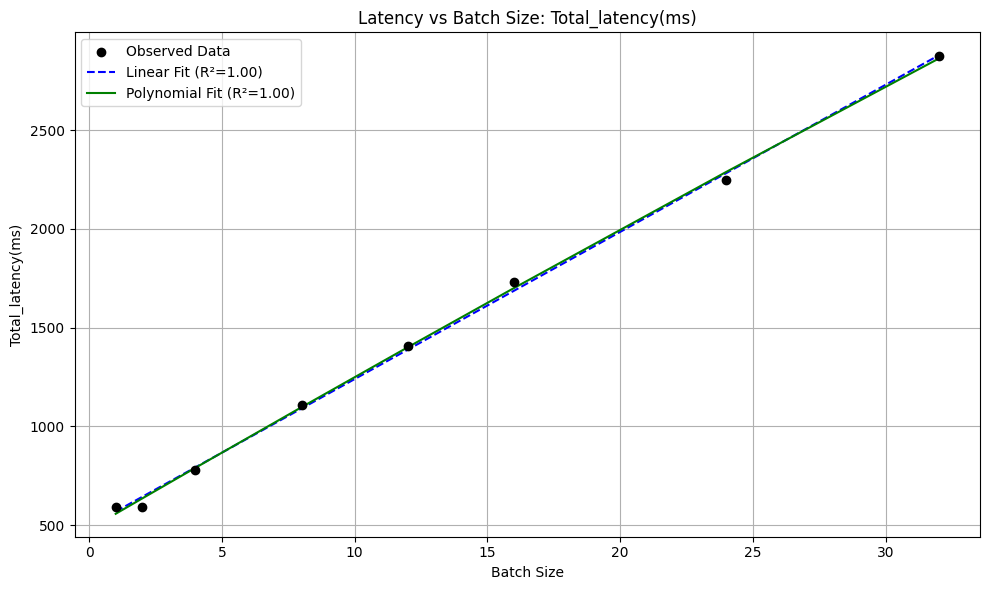

In [16]:
fit_latency_vs_batch_size(attribute='Total_latency(ms)')

In [39]:
def avg_fit_exponential(file_path = '/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv', 
                    attribute = 'total_latency',
                    batch_size = 1):
    
    df = pd.read_csv(file_path)
    df = df[df['batch_size'] == batch_size]
    df_avg_latency = df.groupby('workers_vCPU')[attribute].max().reset_index()

    X = df_avg_latency['workers_vCPU'].values.reshape(-1, 1)
    y = df_avg_latency[attribute].values
    
        
    params, _ = curve_fit(exponential, X.flatten(), y, p0=[500,   -2.40481306,  120], maxfev=10000)
    y_pred_exp = exponential(X.flatten(), *params)
    mse_exp = mean_squared_error(y, y_pred_exp)
    r2_exp = r2_score(y, y_pred_exp)
    
    print(list(params))
    print("\nExponential Regression Results:")
    print(f"MSE: {mse_exp}")
    print(f"R²: {r2_exp}")

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Data', zorder=5)

    # Plot Exponential Regression result
    plt.plot(X, y_pred_exp, color='red', label=f'Exponential Regression (R²={r2_exp:.2f})', zorder=2)

    plt.xlabel('vCPU')
    plt.ylabel('Average Latency (ms)')
    plt.title('Exponential Regression for Latency Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()


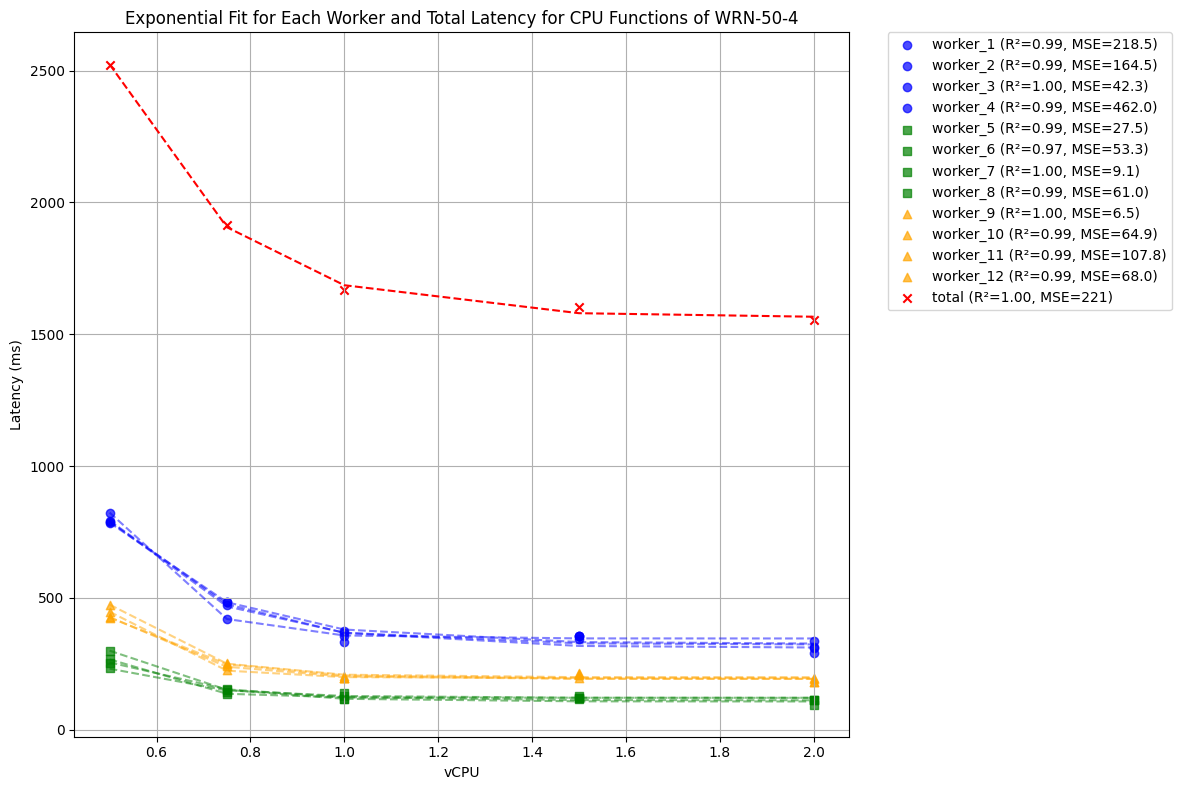

In [54]:
def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def model_all_workers_and_total(file_path='/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv', batch_size=1):
    df = pd.read_csv(file_path)
    df = df[df['batch_size'] == batch_size]

    stage_map = {
        'Stage 1': {'range': range(1, 5), 'color': 'blue', 'marker': 'o'},
        'Stage 2': {'range': range(5, 9), 'color': 'green', 'marker': 's'},
        'Stage 3': {'range': range(9, 13), 'color': 'orange', 'marker': '^'},
    }

    plt.figure(figsize=(12, 8))

    for stage_label, props in stage_map.items():
        for i in props['range']:
            col = f'worker_{i}'
            df_avg = df.groupby('workers_vCPU')[col].mean().reset_index()
            X = df_avg['workers_vCPU'].values
            y = df_avg[col].values
            
            try:
                params, _ = curve_fit(exponential, X, y, p0=[500, -2.0, 100], maxfev=10000)
                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)
                # plt.scatter(X, y, label=f'{col} (R²={r2:.2f})', marker=props['marker'], color=props['color'], alpha=0.7)
                plt.scatter(
                    X, y, 
                    label=f'{col} (R²={r2:.2f}, MSE={mse:.1f})',
                    marker=props['marker'], 
                    color=props['color'], 
                    alpha=0.7
                )
                
                plt.plot(X, y_pred, color=props['color'], linestyle='--', alpha=0.5)
            except RuntimeError:
                print(f"Fit failed for {col}")

    # Total latency
    df_total = df.groupby('workers_vCPU')['total_latency'].mean().reset_index()
    X_total = df_total['workers_vCPU'].values
    y_total = df_total['total_latency'].values

    try:
        params_total, _ = curve_fit(exponential, X_total, y_total, p0=[500, -2.0, 100], maxfev=10000)
        y_pred_total = exponential(X_total, *params_total)
        r2_total = r2_score(y_total, y_pred_total)
        mse_total = mean_squared_error(y_total, y_pred_total)
        plt.scatter(
            X_total, y_total,
            label=f'total (R²={r2_total:.2f}, MSE={mse_total:.0f})',
            marker='x',
            color='red'
        )
        # plt.scatter(X_total, y_total, label=f'Total Latency (R²={r2_total:.2f})', marker='x', color='red')
        plt.plot(X_total, y_pred_total, color='red', linestyle='--')
    except RuntimeError:
        print("Fit failed for total_latency")

    plt.title('Exponential Fit for Each Worker and Total Latency for CPU Functions of WRN-50-4')
    plt.xlabel('vCPU')
    plt.ylabel('Latency (ms)')
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()
    
model_all_workers_and_total()

### SINGLE Functions

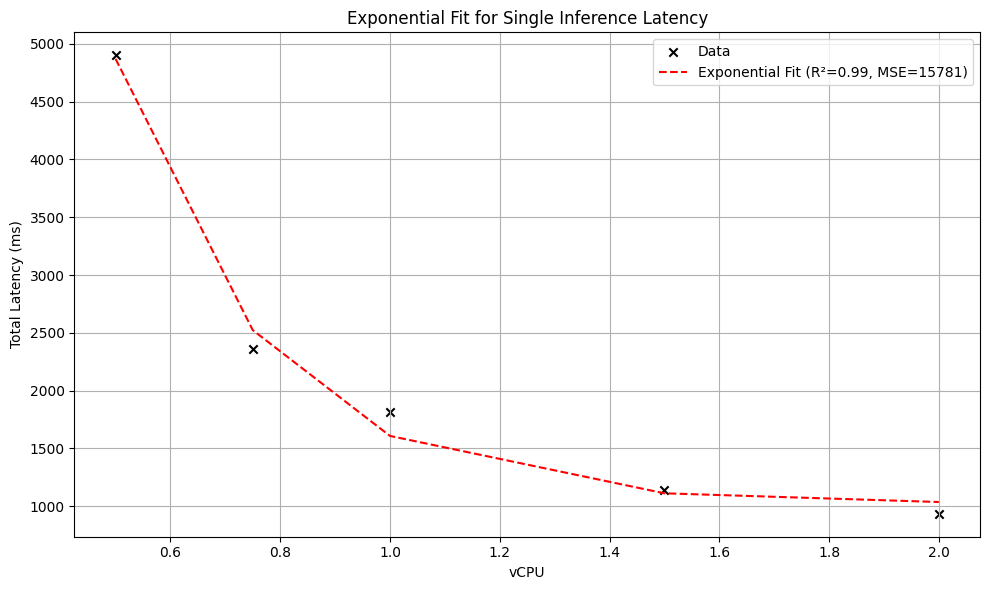

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def model_single_inference_latency(file_path='/mnt/data/HarmonyBatch/wrn50_single_inference_latency.csv'):
    # Load and group by vCPU
    df = pd.read_csv(file_path)
    df_avg = df.groupby('vCPU')['total_latency'].mean().reset_index()
    
    X = df_avg['vCPU'].values
    y = df_avg['total_latency'].values

    try:
        # Fit exponential model
        params, _ = curve_fit(exponential, X, y, p0=[5000, -2.0, 1000], maxfev=10000)
        y_pred = exponential(X, *params)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='black', marker='x', label='Data')
        plt.plot(X, y_pred, color='red', linestyle='--', 
                 label=f'Exponential Fit (R²={r2:.2f}, MSE={mse:.0f})')

        plt.title('Exponential Fit for Single Inference Latency')
        plt.xlabel('vCPU')
        plt.ylabel('Total Latency (ms)')
        plt.grid(True)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

    except RuntimeError:
        print("Fit failed for total_latency")

model_single_inference_latency()

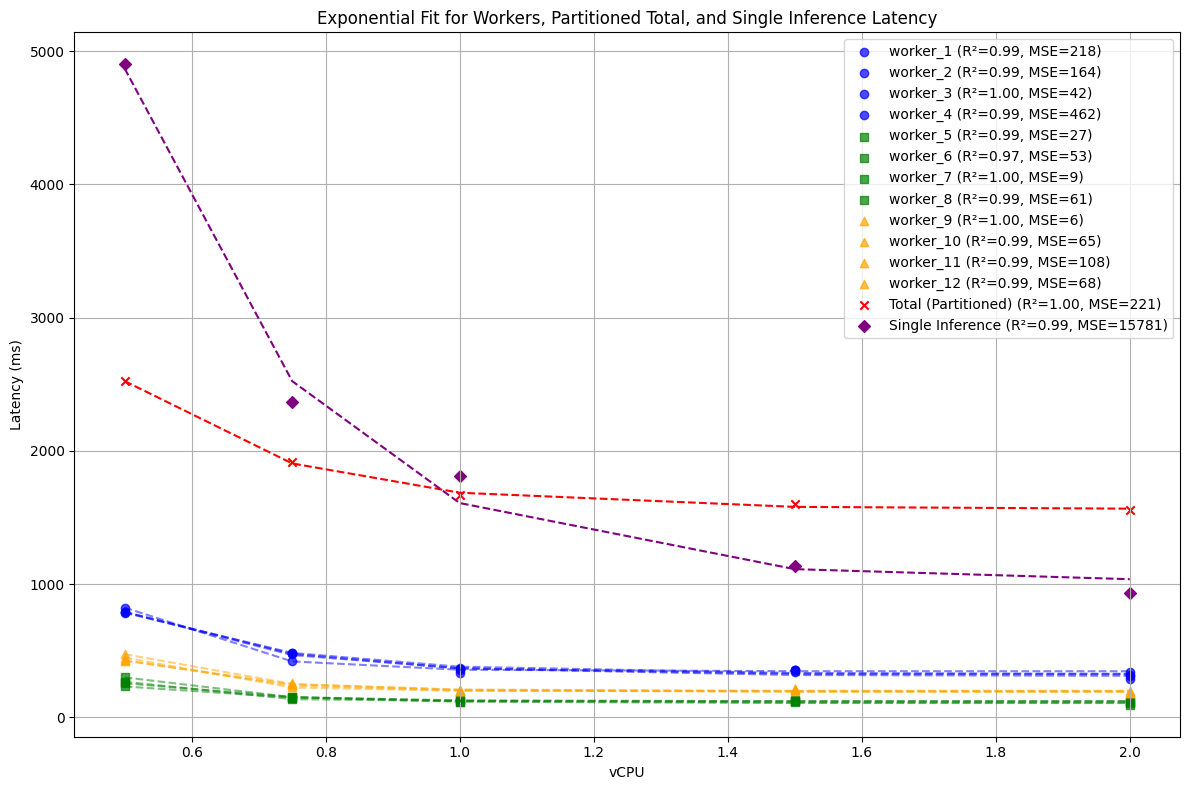

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def model_all_latency_sources(
    partitioned_file='/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv',
    single_file='/mnt/data/HarmonyBatch/wrn50_single_inference_latency.csv',
    batch_size=1
):
    df = pd.read_csv(partitioned_file)
    df = df[df['batch_size'] == batch_size]

    stage_map = {
        'Stage 1': {'range': range(1, 5), 'color': 'blue', 'marker': 'o'},
        'Stage 2': {'range': range(5, 9), 'color': 'green', 'marker': 's'},
        'Stage 3': {'range': range(9, 13), 'color': 'orange', 'marker': '^'},
    }

    plt.figure(figsize=(12, 8))

    # Plot each worker latency
    for stage_label, props in stage_map.items():
        for i in props['range']:
            col = f'worker_{i}'
            df_avg = df.groupby('workers_vCPU')[col].mean().reset_index()
            X = df_avg['workers_vCPU'].values
            y = df_avg[col].values

            try:
                params, _ = curve_fit(exponential, X, y, p0=[500, -2.0, 100], maxfev=10000)
                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)

                plt.scatter(X, y, label=f'{col} (R²={r2:.2f}, MSE={mse:.0f})',
                            marker=props['marker'], color=props['color'], alpha=0.7)
                plt.plot(X, y_pred, linestyle='--', color=props['color'], alpha=0.5)
            except RuntimeError:
                print(f"Fit failed for {col}")

    # Plot total latency from partitioned model
    df_total = df.groupby('workers_vCPU')['total_latency'].mean().reset_index()
    X_total = df_total['workers_vCPU'].values
    y_total = df_total['total_latency'].values

    try:
        params_total, _ = curve_fit(exponential, X_total, y_total, p0=[5000, -2.0, 1000], maxfev=10000)
        y_pred_total = exponential(X_total, *params_total)
        r2_total = r2_score(y_total, y_pred_total)
        mse_total = mean_squared_error(y_total, y_pred_total)

        plt.scatter(X_total, y_total, label=f'Total (Partitioned) (R²={r2_total:.2f}, MSE={mse_total:.0f})',
                    marker='x', color='red')
        plt.plot(X_total, y_pred_total, linestyle='--', color='red')
    except RuntimeError:
        print("Fit failed for total_latency")

    # Plot total latency from single inference
    df_single = pd.read_csv(single_file)
    df_single_avg = df_single.groupby('vCPU')['total_latency'].mean().reset_index()
    X_single = df_single_avg['vCPU'].values
    y_single = df_single_avg['total_latency'].values

    try:
        params_single, _ = curve_fit(exponential, X_single, y_single, p0=[5000, -2.0, 1000], maxfev=10000)
        y_pred_single = exponential(X_single, *params_single)
        r2_single = r2_score(y_single, y_pred_single)
        mse_single = mean_squared_error(y_single, y_pred_single)

        plt.scatter(X_single, y_single, label=f'Single Inference (R²={r2_single:.2f}, MSE={mse_single:.0f})',
                    marker='D', color='purple')
        plt.plot(X_single, y_pred_single, linestyle='--', color='purple')
    except RuntimeError:
        print("Fit failed for single inference")

    # Final plot setup
    plt.title('Exponential Fit for Workers, Partitioned Total, and Single Inference Latency')
    plt.xlabel('vCPU')
    plt.ylabel('Latency (ms)')
    plt.grid(True)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

model_all_latency_sources()

In [14]:
import pandas as pd
# from core import calculate_total_cost_with_workers, Instance # Adjust import if needed
import cost

# Load your CSV
file_path = '/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv'
cost_df = pd.read_csv(file_path)

# Define the batch size used
batch_size = 1

# Function to calculate cost row-wise
def compute_cost(row):
    total_latency = row['total_latency']
    worker_latencies = [row[f'worker_{i}'] for i in range(1, 13)]

    # Create instance objects
    master_instance = Instance(
        vCPU=row['master_vCPU'],
        memory=float(row['master_memory'].replace('mb', '')) / 1024,
        gpu=0
    )
    
    worker_instance = Instance(
        vCPU=row['workers_vCPU'],
        memory=float(row['workers_memory'].replace('mb', '')) / 1024,
        gpu=0
    )

    worker_instances = [worker_instance] * 12  # 12 workers

    # Compute and return cost
    return calculate_total_cost_with_workers(
        total_latency,
        worker_latencies,
        batch_size,
        master_instance,
        worker_instances,
        is_cpu=True
    )

# Apply to DataFrame
cost_df['cost'] = cost_df.apply(compute_cost, axis=1)

# Save updated CSV
# cost_df.to_csv('/mnt/data/wrn50_cpu_profiling_batch1_all_configs_with_cost.csv', index=False)
cost_df.head()


ModuleNotFoundError: No module named 'harmony'

[5140.135005988766, -3.2442882816610523, 1643.4077027541514]

Exponential Regression Results:
MSE: 896.297211937449
R²: 0.9935289025543591


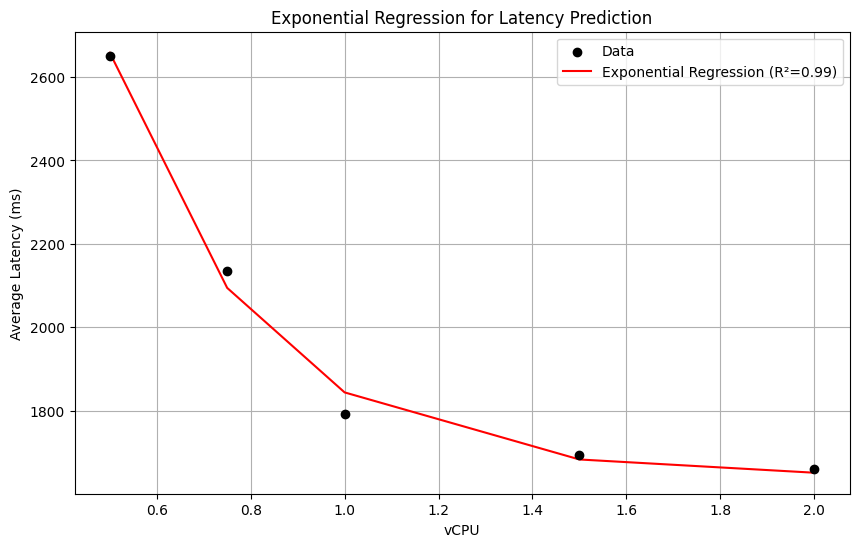

In [40]:
avg_fit_exponential(attribute="total_latency")

NameError: name 'curve_fit' is not defined

In [15]:
params

array([2784.48385955,   -4.43692924,  500.53192111])

In [6]:
df_min_mem_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])
df_min_mem_latency

/tmp/ipykernel_813562/3329862725.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_min_mem_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])


,vCPU,Memory,Batch_size,Avg_latency(ms),Min_latency(ms),Max_latency(ms),Count,Total_cost($)
vCPU,,,,,,,,
0.35,0.35,512.0,1.0,1250.666667,1077.0,1746.0,9.0,0.005746
0.50,0.50,512.0,1.0,1206.555556,828.0,2089.0,9.0,0.007690
0.75,0.75,1024.0,1.0,979.222222,581.0,1867.0,9.0,0.011362
1.00,1.00,1024.0,1.0,885.000000,540.0,1904.0,9.0,0.014602
1.50,1.50,2048.0,1.0,956.222222,519.0,1955.0,9.0,0.022378
2.00,2.00,2048.0,1.0,1024.777778,512.0,2118.0,9.0,0.029074


In [6]:
prof = pd.read_csv('/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv')
prof

,model,batch_size,workers_vCPU,workers_memory,master_vCPU,master_memory,worker_1,worker_2,worker_3,worker_4,...,worker_6,worker_7,worker_8,worker_9,worker_10,worker_11,worker_12,total_latency,overhead_raw,overhead_per_stage
0,WRN-50-4,1,0.50,2048mb,0.5,2048mb,709,708,752,842,...,225,278,270,452,435,394,432,2451,879,293.000000
1,WRN-50-4,1,0.50,2048mb,0.5,2048mb,832,813,756,776,...,225,272,320,404,460,387,453,2471,856,285.333333
2,WRN-50-4,1,0.50,2048mb,0.5,2048mb,857,796,885,715,...,266,220,299,398,419,498,419,2505,823,274.333333
3,WRN-50-4,1,0.50,2048mb,0.5,2048mb,809,774,925,938,...,209,265,304,438,450,553,582,2650,826,275.333333
4,WRN-50-4,1,0.50,2048mb,0.5,2048mb,760,837,800,670,...,238,241,308,444,365,406,485,2534,904,301.333333
5,WRN-50-4,1,0.75,2048mb,0.5,2048mb,513,460,408,418,...,141,163,209,263,224,225,272,2034,1040,346.666667
6,WRN-50-4,1,0.75,2048mb,0.5,2048mb,420,606,397,452,...,142,136,141,247,259,230,258,2135,1124,374.666667
7,WRN-50-4,1,0.75,2048mb,0.5,2048mb,505,471,426,455,...,142,115,151,216,212,204,230,1774,888,296.000000
8,WRN-50-4,1,0.75,2048mb,0.5,2048mb,419,537,409,514,...,130,198,153,223,280,217,296,1866,835,278.333333
9,WRN-50-4,1,0.75,2048mb,0.5,2048mb,570,389,424,534,...,179,159,137,306,270,199,229,1944,889,296.333333


In [5]:
from latency import UnifiedLatency

# Example usage: batch size 1, average model
model = UnifiedLatency(config_path="config.json", batch_size=1, model_type="avg")

# Predict total latency for 1.0 vCPU
total_latency = model.lat(vcpu=1.0)
print(f"Predicted total avg latency (1.0 vCPU): {total_latency:.2f} ms")

# Predict latency for worker 3 (example)
worker_latency = model.lat(vcpu=1.0, worker_id=3)
print(f"Predicted avg latency of worker 3 (1.0 vCPU): {worker_latency:.2f} ms")

ModuleNotFoundError: No module named 'harmony'